# Combined figure — loss curves (row 1) + alignment curves with inset (row 2)

Layout: **2 rows × 4 columns**.

- **Row 1** — training-loss curves
  - **Column 1** — Pattern generation: BPTT vs. E-prop vs. Diffusion.
  - **Column 2** — Pattern generation again, but comparing two *tests* of the diffusion rule: plain diffusion vs. shuffled diffusion (nearest-neighbours connectivity). 
  - **Column 3** — Delayed match: BPTT vs. E-prop vs. Diffusion.
  - **Column 4** — Cue accumulation: BPTT vs. E-prop vs. Diffusion.
- **Row 2** — alignment curves with pairwise-difference inset (`plot_curves_with_diff_inset`-style)
  - **Columns 1, 3, 4** — within-training comparison: tags (e.g. `diffusion_aligned` (diffusion) vs `eprop`) evaluated on the *same* training run, one per task (Pattern generation | Delayed match | Cue accumulation).
  - **Column 2** — *self-alignment* comparison: the `diffusion_aligned` (diffusion) tag is taken from the run **trained with** `diffusion_aligned` (diffusion), and the `diffusion_fixed` (shuffled diffusion) tag is taken from the run **trained with** `diffusion_fixed` (suffled diffusion) — each rule evaluated under its own training dynamics, not against another rule within one run.

Tags:
- `diffusion_aligned`: is used for the standard diffusion, where diffusion grid and connectivity grid are spatially aligned
- `diffusion_fixed`: is used for the shuffled diffusion condition, where the spatial position of the diffusion grid was shuffled once before the training and then kept fixed, creating the spatial misalignment between diffusion and connectivity grids

## 1 — Imports & path setup

In [1]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import os
import pickle
from pathlib import Path
import sys
from scipy import stats as _stats


# ── make the directory that contains plot_figs.py importable ──────────────────
# By default we assume plot_figs.py lives next to this notebook.
SCRIPTS_DIR = Path.cwd()
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))


from load_runs import load_runs

%matplotlib inline

## 2 — Configuration

**Edit this cell** to point at your data.

In [2]:
# Change accordingly to where results are saved
# ── Root of the outputs tree ──────────────────────────────────────────────────
FIG2_DIR= Path.cwd()
ROOT = FIG2_DIR / "saved_results" 


In [3]:

# ── Tasks ──────────────────────────────────────────────────────────────────────
TASKS = [
    "pattern_generation",
    "delayed_match",
    "cue_accumulation",
]

TITLE_MAP = {
    "pattern_generation": "Pattern generation",
    "delayed_match":      "Delayed match-to-sample",
    "cue_accumulation":   "Cue accumulation",
}

# ── Figure dimensions ─────────────────────────────────────────────────────────
cm = 1 / 2.54
N_COLS = 4
PANEL_WIDTH_CM = 11.7 / 4   
fig_w = PANEL_WIDTH_CM * N_COLS * cm   # total width
fig_h = 4.2 * cm                       # total height 

# ── Row 1: loss-curve experiment names & display parameters  ─────
# One experiment-folder name per rule, same order as LOSS_LABELS.
# The full path is built as ROOT / task / experiment_name.
LOSS_EXPERIMENT_NAMES = {
    "pattern_generation": ["BPTT", "e_prop_hardcoded", "diffusion"],
    "delayed_match":      ["BPTT", "e_prop_hardcoded", "diffusion"],
    "cue_accumulation":   ["BPTT", "e_prop_hardcoded", "diffusion"],
}

# Metric files per task for row 1 (pattern_generation uses nMSE, others Cross-Entropy)
LOSS_METRIC_FILES = {
    "pattern_generation": "normalized_loss_eval.pkl",
    "delayed_match":       "loss_eval.pkl",
    "cue_accumulation":    "loss_eval.pkl",
}

LOSS_YLABELS = {
    "pattern_generation": "nMSE",
    "delayed_match":       "Cross-Entropy",
    "cue_accumulation":    "Cross-Entropy",
}

LOSS_YLIMS = {
    "pattern_generation": (0, 0.4),
    "delayed_match":       (0, 0.735),
    "cue_accumulation":    (0, 0.735),
}

LOSS_YTICKS = {
    "pattern_generation": [0.05, 0.15, 0.25, 0.35],
    "delayed_match":       [0.1, 0.3, 0.5, 0.7],
    "cue_accumulation":    [0.10, 0.3, 0.5, 0.7],
}

LOSS_LABELS   = ["BPTT", "Sparse e-prop", "Diffusion"]
LOSS_COLORS   = ["#C20017", "#cac100ff", "#23AA00"]

# ── Row 2: alignment data configuration   ─────────────────────────
EXPERIMENT_NAME        = "align_local_connectivity"
TRAINING_LEARNING_RULE = "diffusion_aligned"
FILE_NAME = EXPERIMENT_NAME + "_" + TRAINING_LEARNING_RULE

LAYER  = "recurrent_weights" # "input_weights"
METRIC = "angle" # "norm"

TAG_ORDER = [
    "diffusion_aligned",
    "eprop",
]

TAG_COLORS = {
    "BPTT":               "#C20017",
    "eprop":              "#cac100ff",
    "diffusion_aligned":  "#23AA00",
    "diffusion_fixed":    "#6E0385",
}

REFERENCE    = "diffusion_aligned"
ALPHA        = 0.05
SKIP_FIRST_N = 1
LABEL_PAD = 0.5
# Inset position in axes-fraction coordinates (left, bottom, width, height).
INSET_BOUNDS = (0.55, 0.10, 0.35, 0.40)

# ── Row 2: alignment plot display parameters  ───────────────────
ROW2_YLIM   = (0, 70)
ROW2_YTICKS = [10, 30, 50, 70]
ROW2_YLABEL = "alignment \n angle (\u00b0)"
ROW2_XLABEL = "Iteration"
ROW2_XTICKS = {
    "pattern_generation": [0, 1000, 2000],
    "delayed_match":     [0, 1000, 2000],
    "cue_accumulation":  [0, 1000, 2000],
}
ROW2_INSET_YLABEL = "\u0394 angle (\u00b0)"

# Font-size offset (relative to the base `font.size` rcParam) applied to the
# inset tick labels and inset y-label. 
INSET_FONTSIZE_DELTA = -2

STAR_OFFSET_EM = 0.6

# ── Column 2: Pattern generation — diffusion vs. shuffled diffusion - nearest neighbor conenctivity ────
COL2_TASK  = "pattern_generation"
COL2_TITLE = "nearest neighbors only"

COL2_LOSS_EXPERIMENT_NAMES = ["diffusion_nn", "fixed_shuffle_diffusion_nn"]
COL2_LOSS_LABELS = ["Diffusion", "Shuffled \n diffusion"]
COL2_LOSS_COLORS = ["#23AA00",  "#6E0385"]

COL2_LOSS_METRIC_FILE = LOSS_METRIC_FILES["pattern_generation"]
COL2_LOSS_YLIM        = LOSS_YLIMS["pattern_generation"]
COL2_LOSS_YTICKS      = LOSS_YTICKS["pattern_generation"]

# Row 2 (self-alignment curves + inset) ───────────────────────────────────────
COL2_EXPERIMENT_NAME  = "align_nn_connectivity"
COL2_SELF_ALIGN_RULES = ["diffusion_aligned", "diffusion_fixed"]  # "diffusion_fixed" == shuffled-diffusion control

COL2_SELF_ALIGN_LABELS = {
    "diffusion_aligned": "Diffusion",
    "diffusion_fixed":   "Shuffled \n diffusion",
}
COL2_SELF_ALIGN_COLORS = {
    "diffusion_aligned": "#23AA00",
    "diffusion_fixed":    "#6E0385",
}

COL2_XTICKS = None

# Reference rule for the inset pairwise-difference box plot
COL2_REFERENCE = "diffusion_aligned"

# Output paths
OUTPUT_PDF = "Fig2.pdf"
OUTPUT_SVG = "Fig2.svg"


## 3 — Global matplotlib style

In [4]:
plt.rcParams["axes.edgecolor"]  = "k"
plt.rcParams["axes.facecolor"]  = "w"
plt.rcParams["axes.linewidth"]  = "0.8"
plt.rcParams.update({"font.size": 6})
plt.rcParams["savefig.dpi"]     = 300
plt.rcParams["pdf.fonttype"]    = 42   
plt.rcParams["ps.fonttype"]     = 42
plt.rcParams.update({"axes.titlesize": 6})
plt.rcParams.update({"legend.fontsize": 6})
plt.rcParams["font.family"]     = "Arial"

## 4 — Helper: plot_multiruns (row 1)


In [5]:
def plot_multiruns(root, task, experiment_name, label, metric_file, ax, color):
    """Plot mean ± 95 % CI loss across all seed runs for one experiment.

    Seed run directories are expected directly inside::

        root / task / experiment_name / <seed_dir> / train_info / <metric_file>

    Parameters
    ----------
    root : Path
        Root of the outputs tree.
    task : str
        Task name (e.g. ``"pattern_generation"``).
    experiment_name : str
        Experiment folder name under ``root / task /``
        (e.g. ``"BPTT"``, ``"diffusion"``).
    label : str
        Legend label for this curve.
    metric_file : str
        Pickle filename inside the ``train_info`` sub-directory
        (e.g. ``"loss_eval.pkl"``).
    ax : matplotlib.axes.Axes
        Axes on which to draw the curve.
    color : str
        Line and fill colour.
    """
    experiment_folder = root / task / experiment_name
    loss_all_runs = []

    for run_folder in os.listdir(experiment_folder):
        run_path = experiment_folder / run_folder
        if run_path.is_dir():
            train_info_folder = run_path / "train_info"
            if train_info_folder.exists():
                file_path = train_info_folder / metric_file
                with open(file_path, "rb") as f:
                    loss_all_runs.append(pickle.load(f))

    max_epochs = max(len(r) for r in loss_all_runs)
    losses_padded = np.array([
        np.pad(r, (0, max_epochs - len(r)), "constant", constant_values=np.nan)
        for r in loss_all_runs
    ])

    mean_loss  = np.nanmean(losses_padded, axis=0)
    std_dev    = np.nanstd(losses_padded, axis=0)
    num_samples = np.sum(~np.isnan(losses_padded), axis=0)
    std_error  = std_dev / np.sqrt(num_samples)
    lower_ci   = np.clip(mean_loss - 1.96 * std_error, 0, None)
    upper_ci   = mean_loss + 1.96 * std_error

    epochs = np.arange(0, max_epochs * 25, 25)
    ax.plot(epochs, mean_loss, label=label, c=color, linewidth=0.5)
    ax.fill_between(epochs, lower_ci, upper_ci, color=color, alpha=0.4, linewidth=0.5)


## 5 — Load alignment data (row 2, columns 1,3, and 4)

In [6]:
runs = load_runs(
    root=ROOT,
    experiment_name=FILE_NAME,
    tasks=TASKS,
    layer=LAYER,
    metric=METRIC,
)

if not runs:
    raise RuntimeError(
        f"No usable runs found under {ROOT}/<task>/{FILE_NAME}/. "
        "Check ROOT, FILE_NAME, and TASKS in the Configuration cell."
    )

print("Loaded tasks:", list(runs.keys()))

Loaded tasks: ['pattern_generation', 'delayed_match', 'cue_accumulation']


## 5b — Load self-alignment data (row 2, column 2)

In [7]:
col2_runs_per_rule = {}
for rule in COL2_SELF_ALIGN_RULES:
    exp_name = COL2_EXPERIMENT_NAME + "_" + rule
    try:
        rule_runs = load_runs(
            root=ROOT,
            experiment_name=exp_name,
            tasks=[COL2_TASK],
            layer=LAYER,
            metric=METRIC,
        )
    except Exception as exc:
        print(f"Warning: could not load runs for column-2 rule '{rule}': {exc}; skipping.")
        continue

    if rule_runs and COL2_TASK in rule_runs:
        col2_runs_per_rule[rule] = rule_runs
    else:
        print(
            f"Warning: no data found for column-2 rule '{rule}' "
            f"(experiment: {exp_name}); skipping."
        )

if not col2_runs_per_rule:
    print(
        "Warning: no column-2 self-alignment data loaded. Column 2, row 2 "
        "will be left empty -- check COL2_EXPERIMENT_NAME, "
        "COL2_SELF_ALIGN_RULES, and COL2_TASK in the Configuration cell."
    )

print("Loaded column-2 training rules:", list(col2_runs_per_rule.keys()))

Loaded column-2 training rules: ['diffusion_aligned', 'diffusion_fixed']


## 6 — Build figure

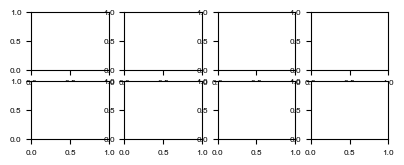

In [8]:


fig = plt.figure(figsize=(fig_w, fig_h))

# 2 rows, 4 columns — equal height and width
gs = gridspec.GridSpec(
    2, N_COLS,
    figure=fig,
    height_ratios=[1, 1],
    width_ratios=[1, 1, 1, 1],
)

# ── Row 1 axes ────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])               # Pattern generation  (loss)
ax7 = fig.add_subplot(gs[0, 1], sharey=ax1)    # Pattern generation, diffusion vs. shuffled (loss) – nearest neighbor
ax2 = fig.add_subplot(gs[0, 2], sharey=None)   # Delayed match       (loss) 
ax3 = fig.add_subplot(gs[0, 3], sharey=ax2)    # Cue accumulation    (loss) 

# ── Row 2 axes ────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0], sharex=ax1)               # Pattern generation  (alignment)
ax8 = fig.add_subplot(gs[1, 1], sharex=ax7, sharey=ax4)    # self-alignment, diffusion vs. shuffled – nearest neighbor
ax5 = fig.add_subplot(gs[1, 2], sharex=ax2, sharey=ax4)    # Delayed match
ax6 = fig.add_subplot(gs[1, 3], sharex=ax3, sharey=ax4)    # Cue accumulation

row1_axes = [ax1, ax2, ax3]
row2_axes = [ax4, ax5, ax6]

### 6a — Row 1: loss curves (columns 1,3,4)

In [9]:
_legend_handles = []
_legend_labels  = []

for col_idx, (task, ax) in enumerate(zip(TASKS, row1_axes)):
    exp_names = LOSS_EXPERIMENT_NAMES[task]
    mfile     = LOSS_METRIC_FILES[task]
    ylim      = LOSS_YLIMS[task]
    yticks    = LOSS_YTICKS[task]

    for exp_name, label, color in zip(exp_names, LOSS_LABELS, LOSS_COLORS):
        plot_multiruns(
            root=ROOT,
            task=task,
            experiment_name=exp_name,
            label=label,
            metric_file=mfile,
            ax=ax,
            color=color,
        )

    # Cosmetics
    ax.set_title(TITLE_MAP[task])
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)

    if (col_idx == 0) | (col_idx == 1):
        ax.set_ylabel(LOSS_YLABELS[task], labelpad=LABEL_PAD)
    else:
        ax.set_ylabel("")

   
    plt.setp(ax.get_xticklabels(), visible=False)
    ax.tick_params(axis="x", labelbottom=False)
    ax.tick_params(axis="both", pad=LABEL_PAD)

# ── Collect legend handles from the first axis ────────────────────────────────
_legend_handles, _legend_labels = ax1.get_legend_handles_labels()

# Place legend on top-left axis only
ax1.legend(
    _legend_handles, _legend_labels,
    frameon=False,
    bbox_to_anchor=(0.20, 0.38),
    handlelength=0.4,
    handletextpad=0.4,
    labelspacing=0.1,
)
# hide other legends
for _ax in [ax2, ax3]:
    leg = _ax.get_legend()
    if leg:
        leg.set_visible(False)


### 6a′ — Row 1, column 2: diffusion vs. shuffled diffusion

In [10]:
for exp_name, label, color in zip(COL2_LOSS_EXPERIMENT_NAMES, COL2_LOSS_LABELS, COL2_LOSS_COLORS):
    plot_multiruns(
        root=ROOT,
        task=COL2_TASK,
        experiment_name=exp_name,
        label=label,
        metric_file=COL2_LOSS_METRIC_FILE,
        ax=ax7,
        color=color,
    )

# Cosmetics
ax7.set_title(COL2_TITLE)
ax7.spines["right"].set_visible(False)
ax7.spines["top"].set_visible(False)
ax7.set_ylim(*COL2_LOSS_YLIM)
ax7.set_yticks(COL2_LOSS_YTICKS)
ax7.set_ylabel("")  

plt.setp(ax7.get_xticklabels(), visible=False)
ax7.tick_params(axis="x", labelbottom=False)
ax7.tick_params(axis="both", pad=LABEL_PAD)

_col2_handles, _col2_labels = ax7.get_legend_handles_labels()
ax7.legend(
    _col2_handles, _col2_labels,
    frameon=False,
    loc="upper right",
    handlelength=0.4,
    handletextpad=0.4,
    labelspacing=0.1,
)


### 6b — Row 2, columns 1,3,4: alignment curves with pairwise-difference inset

In [11]:
_METRIC_CONVERTERS = {
    "angle": lambda x: np.asarray(x) * 180.0 / np.pi,
    "norm":  lambda x: np.asarray(x, dtype=float),
}
convert = _METRIC_CONVERTERS[METRIC]

cmap_fallback = plt.get_cmap("tab10")

def _significance_stars(pval):
    """Map a p-value to the conventional star notation.

    * = p < 0.05, ** = p < 0.01, *** = p < 0.001. Returns "" if not significant.
    """
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    return ""


def _annotate_significance_star(ax_ins, x_pos, bp, box_index, pval, fontsize, offset_em):
    """Place a significance-star label just right of, and below the top of,
    the upper whisker for box `box_index` in a boxplot `bp` on `ax_ins`.

    `offset_em` sets the horizontal offset (in points) as a multiple of
    `fontsize`, so the offset scales naturally with the star/text size.
    """
    stars = _significance_stars(pval)
    if not stars:
        return

    # Top of the upper whisker for this box (whiskers are stored as
    # [lower_0, upper_0, lower_1, upper_1, ...] pairs per box).
    upper_whisker = bp["whiskers"][2 * box_index + 1]
    whisker_top = max(upper_whisker.get_ydata())

    x_offset_pts = offset_em * fontsize

    ax_ins.annotate(
        stars,
        xy=(x_pos, whisker_top),
        xytext=(x_offset_pts, -1.5),
        textcoords="offset points",
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold",
    )


print("=" * 60)
print(f"Inset statistical tests  (H₁: difference > 0,  alpha={ALPHA})")
print(f"Metric: {METRIC}  |  Layer: {LAYER}")
print(f"Difference: other_rule − '{REFERENCE}'")
if SKIP_FIRST_N > 0:
    print(f"Skipping first {SKIP_FIRST_N} iteration(s) for inset & stats.")
print("=" * 60)

inset_axes_list = []  # collect to control label visibility later

for col_idx, (task, ax) in enumerate(zip(TASKS, row2_axes)):
    run = runs[task]
    available = run["tags"]
    order = [t for t in TAG_ORDER if t in available]
    if not order:
        ax.set_visible(False)
        inset_axes_list.append(None)
        continue

    values     = run.get("values", run)
    iterations = run["iterations"]

    # ── Main alignment curves ─────────────────────────────────────
    for tag in order:
        color     = TAG_COLORS.get(tag, cmap_fallback(order.index(tag) % 10))
        raw       = values[tag]            # (n_seeds, n_iter)
        converted = convert(raw)
        n_seeds   = converted.shape[0]
        mean      = converted.mean(axis=0)

        ax.plot(iterations, mean, color=color, label=tag, linewidth=0.5)

        if n_seeds >= 2:
            std_err = converted.std(axis=0, ddof=1) / np.sqrt(n_seeds)
            ax.fill_between(
                iterations,
                mean - 1.96 * std_err,
                mean + 1.96 * std_err,
                color=color, alpha=0.2, linewidth=0,
            )

    # Cosmetics
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(*ROW2_YLIM)
    ax.set_yticks(ROW2_YTICKS)
    if ROW2_XTICKS.get(task) is not None:
        ax.set_xticks(ROW2_XTICKS[task])
    if METRIC == "angle":
        ax.axhline(90, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)

    
    ax.set_ylabel(ROW2_YLABEL if col_idx == 0 else "", labelpad=LABEL_PAD)

    
    ax.set_xlabel(ROW2_XLABEL, labelpad=LABEL_PAD)
    ax.tick_params(axis="both", pad=LABEL_PAD)

    # ── Inset: pairwise-difference box plots ──────────────────────────────
    if REFERENCE not in run["tags"]:
        inset_axes_list.append(None)
        continue

    ref_arr = convert(values[REFERENCE])
    if SKIP_FIRST_N > 0:
        ref_arr = ref_arr[:, SKIP_FIRST_N:]

    available_others = [t for t in order if t != REFERENCE]
    if not available_others:
        inset_axes_list.append(None)
        continue

    diff_data = {}
    for tag in available_others:
        other_arr = convert(values[tag])
        if SKIP_FIRST_N > 0:
            other_arr = other_arr[:, SKIP_FIRST_N:]
        diff_data[tag] = (other_arr - ref_arr).flatten()

    l, b, w, h = INSET_BOUNDS
    ax_ins = ax.inset_axes([l, b, w, h])
    inset_axes_list.append(ax_ins)

    box_data = [diff_data[t] for t in available_others]
    flierprops = {"marker":"o", "markersize":1.0, "linestyle":"none"}
    try:
        bp = ax_ins.boxplot(
            box_data,
            tick_labels=available_others,
            patch_artist=True,
            showfliers=False,
            widths=0.5,
            flierprops=flierprops,
        )
    except TypeError:
        bp = ax_ins.boxplot(
            box_data,
            labels=available_others,
            patch_artist=True,
            showfliers=False,
            widths=0.5,
            flierprops=flierprops,
        )

    for i, (tag, patch) in enumerate(zip(available_others, bp["boxes"])):
        color = TAG_COLORS.get(tag, cmap_fallback(i % 10))
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for element in ["whiskers", "caps", "medians"]:
        for line in bp[element]:
            line.set_linewidth(0.6)

    ax_ins.axhline(0, color="black", linestyle="-", linewidth=0.6, alpha=0.6)
    ax_ins.spines["top"].set_visible(False)
    ax_ins.spines["right"].set_visible(False)
    _fs = plt.rcParams.get("font.size", 7) + INSET_FONTSIZE_DELTA
    ax_ins.tick_params(axis="both", labelsize=_fs)

    ax_ins.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_ins.tick_params(axis="both", pad=LABEL_PAD)
    ax_ins.set_ylabel(ROW2_INSET_YLABEL, labelpad=LABEL_PAD,
                          fontsize=plt.rcParams.get("font.size", 7) + INSET_FONTSIZE_DELTA)
    # ── Statistical tests & star annotation ─────────────────────────────
    print(f"\nTask: {task}")
    for i, tag in enumerate(available_others):
        diff = diff_data[tag]
        try:
            result = _stats.wilcoxon(diff, alternative="greater", zero_method="wilcox")
            pval, stat_val = result.pvalue, result.statistic
            sig = pval < ALPHA
        except Exception as exc:
            print(f"  ({tag} − {REFERENCE}) > 0: test failed — {exc}")
            pval = stat_val = float("nan")
            sig = False

        stars = _significance_stars(pval)
        print(
            f"  ({tag} − {REFERENCE}) > 0:  W = {stat_val:.1f},  p = {pval:.4g}"
            + (f"  {stars}" if stars else "")
        )

        _inset_fontsize = plt.rcParams.get("font.size", 7) + INSET_FONTSIZE_DELTA
        _annotate_significance_star(
            ax_ins, i + 1, bp, i, pval,
            fontsize=_inset_fontsize, offset_em=STAR_OFFSET_EM,
        )

print("\n" + "=" * 60)



Inset statistical tests  (H₁: difference > 0,  alpha=0.05)
Metric: angle  |  Layer: recurrent_weights
Difference: other_rule − 'diffusion_aligned'
Skipping first 1 iteration(s) for inset & stats.

Task: pattern_generation
  (eprop − diffusion_aligned) > 0:  W = 308728.0,  p = 1.511e-114  ***

Task: delayed_match
  (eprop − diffusion_aligned) > 0:  W = 172769.0,  p = 0.02728  *

Task: cue_accumulation
  (eprop − diffusion_aligned) > 0:  W = 253595.0,  p = 1.362e-46  ***



### 6b′ — Row 2, column 2: self-alignment curves with pairwise-difference inset

This column compares each rule against itself under its own training: the curve for `COL2_SELF_ALIGN_RULES[i]` always comes from the run **trained with** `COL2_SELF_ALIGN_RULES[i]` (the loading done in section 5b). The inset shows the pooled pairwise difference (other rule − `COL2_REFERENCE`).

In [12]:
_col2_rules_present = [r for r in COL2_SELF_ALIGN_RULES if r in col2_runs_per_rule]

if not _col2_rules_present:
    ax8.set_visible(False)
else:
    self_values = {}       
    self_iterations = None

    for rule in _col2_rules_present:
        run = col2_runs_per_rule[rule][COL2_TASK]
        values = run.get("values", run)
        if rule not in values:
            print(
                f"Warning: tag '{rule}' missing from the run trained with "
                f"'{rule}' (available: {list(values.keys())}); skipping."
            )
            continue

        raw       = values[rule]            # (n_seeds, n_iter)
        converted = convert(raw)
        self_values[rule] = converted
        self_iterations = run["iterations"]

        color = COL2_SELF_ALIGN_COLORS.get(
            rule, cmap_fallback(_col2_rules_present.index(rule) % 10)
        )
        label = COL2_SELF_ALIGN_LABELS.get(rule, rule)
        n_seeds = converted.shape[0]
        mean    = converted.mean(axis=0)

        ax8.plot(self_iterations, mean, color=color, label=label, linewidth=0.5)

        if n_seeds >= 2:
            std_err = converted.std(axis=0, ddof=1) / np.sqrt(n_seeds)
            ax8.fill_between(
                self_iterations,
                mean - 1.96 * std_err,
                mean + 1.96 * std_err,
                color=color, alpha=0.2, linewidth=0,
            )

    # Cosmetics
    ax8.spines["top"].set_visible(False)
    ax8.spines["right"].set_visible(False)
    ax8.set_ylim(*ROW2_YLIM)
    ax8.set_yticks(ROW2_YTICKS)
    if COL2_XTICKS is not None:
        ax8.set_xticks(COL2_XTICKS)
    if METRIC == "angle":
        ax8.axhline(90, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)
    ax8.set_ylabel("")   
    ax8.set_xlabel(ROW2_XLABEL, labelpad=LABEL_PAD)   
    ax8.tick_params(axis="both", pad=LABEL_PAD)
    # ── Inset: pairwise-difference box plot (other − COL2_REFERENCE) ───────────
    if COL2_REFERENCE not in self_values:
        print(
            f"Warning: reference rule '{COL2_REFERENCE}' not available for "
            "column 4; skipping inset."
        )
    else:
        ref_arr = self_values[COL2_REFERENCE]
        if SKIP_FIRST_N > 0:
            ref_arr = ref_arr[:, SKIP_FIRST_N:]

        others = [r for r in _col2_rules_present if r != COL2_REFERENCE and r in self_values]

        if others:
            diff_data = {}
            for rule in others:
                other_arr = self_values[rule]
                if SKIP_FIRST_N > 0:
                    other_arr = other_arr[:, SKIP_FIRST_N:]
                # Guard against mismatched iteration counts between the two
                # training-rule runs (e.g. different early-stopping points).
                n_common = min(ref_arr.shape[1], other_arr.shape[1])
                diff_data[rule] = (other_arr[:, :n_common] - ref_arr[:, :n_common]).flatten()

            l, b, w, h = INSET_BOUNDS
            ax_ins8 = ax8.inset_axes([l, b, w, h])

            box_data   = [diff_data[r] for r in others]
            box_labels = [COL2_SELF_ALIGN_LABELS.get(r, r) for r in others]
            flierprops = {"marker":"o", "markersize":1.0, "linestyle":"none"}
            try:
                bp = ax_ins8.boxplot(
                    box_data, tick_labels=box_labels, patch_artist=True,
                    showfliers=False, widths=0.5, flierprops=flierprops,
                )
            except TypeError:
                bp = ax_ins8.boxplot(
                    box_data, labels=box_labels, patch_artist=True,
                    showfliers=False, widths=0.5, flierprops=flierprops,
                )

            for i, (rule, patch) in enumerate(zip(others, bp["boxes"])):
                color = COL2_SELF_ALIGN_COLORS.get(rule, cmap_fallback(i % 10))
                patch.set_facecolor(color)
                patch.set_alpha(0.7)

            for element in ["whiskers", "caps", "medians"]:
                for line in bp[element]:
                    line.set_linewidth(0.6)

            ax_ins8.axhline(0, color="black", linestyle="-", linewidth=0.6, alpha=0.6)
            ax_ins8.spines["top"].set_visible(False)
            ax_ins8.spines["right"].set_visible(False)
            _fs8 = plt.rcParams.get("font.size", 7) + INSET_FONTSIZE_DELTA
            ax_ins8.tick_params(axis="both", labelsize=_fs8, pad=LABEL_PAD)
    
            ax_ins8.tick_params(axis="x", bottom=False, labelbottom=False)
            ax_ins8.set_ylabel("")   
            ax_ins8.set_ylabel(ROW2_INSET_YLABEL, labelpad=LABEL_PAD,
                          fontsize=_fs8)
            # ── Statistical test & star annotation ─────────────────
            print(f"\nColumn 2 ({COL2_TASK}, self-alignment): diffusion vs. shuffled diffusion")
            for i, rule in enumerate(others):
                diff = diff_data[rule]
                try:
                    result = _stats.wilcoxon(diff, alternative="greater", zero_method="wilcox")
                    pval, stat_val = result.pvalue, result.statistic
                    sig = pval < ALPHA
                except Exception as exc:
                    print(f"  ({rule} − {COL2_REFERENCE}) > 0: test failed — {exc}")
                    pval = stat_val = float("nan")
                    sig = False

                stars = _significance_stars(pval)
                print(
                    f"  ({rule} − {COL2_REFERENCE}) > 0:  W = {stat_val:.1f},  p = {pval:.4g}"
                    + (f"  {stars}" if stars else "")
                )

                _inset_fontsize8 = plt.rcParams.get("font.size", 7) + INSET_FONTSIZE_DELTA
                _annotate_significance_star(
                    ax_ins8, i + 1, bp, i, pval,
                    fontsize=_inset_fontsize8, offset_em=STAR_OFFSET_EM,
                )



Column 2 (pattern_generation, self-alignment): diffusion vs. shuffled diffusion
  (diffusion_fixed − diffusion_aligned) > 0:  W = 244660.0,  p = 1.778e-38  ***


## 7 — Final layout & save

In [13]:
fig.subplots_adjust(
    left=0.10,
    right=0.99,
    top=0.88,
    bottom=0.17,
    wspace=0.35,
    hspace=0.25,
)

fig.savefig(OUTPUT_PDF, format="pdf")
fig.savefig(OUTPUT_SVG, format="svg")
plt.show()
print(f"Saved {OUTPUT_PDF} and {OUTPUT_SVG}")

Saved Fig2.pdf and Fig2.svg
